# 02 — Explore & describe: NOAA daily weather (Central Park, 2025)

Loads the weather CSV downloaded by `00_download.ipynb`, plots TMAX/TMIN/PRCP/SNOW over time,
sanity-checks units, and checks for missing calendar days. Descriptive only — no cleaning here.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

print("python", sys.version)
print("pandas", pd.__version__)

python 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas 2.3.3


## Load

In [2]:
wx = pd.read_csv("../data/raw/weather_centralpark_2025_downloaded_2026-07-12.csv")
wx["DATE"] = pd.to_datetime(wx["DATE"])
print(wx.shape)
wx.head()

(243, 6)


,STATION,DATE,PRCP,SNOW,TMAX,TMIN
0,USW00094728,2025-01-01,0.0,0.0,10.6,3.9
1,USW00094728,2025-01-02,0.0,0.0,6.1,0.6
2,USW00094728,2025-01-03,0.0,0.0,3.9,-0.5
3,USW00094728,2025-01-04,0.0,0.0,0.6,-2.1
4,USW00094728,2025-01-05,0.0,0.0,0.6,-2.1


## Plot TMAX / TMIN / PRCP / SNOW over time

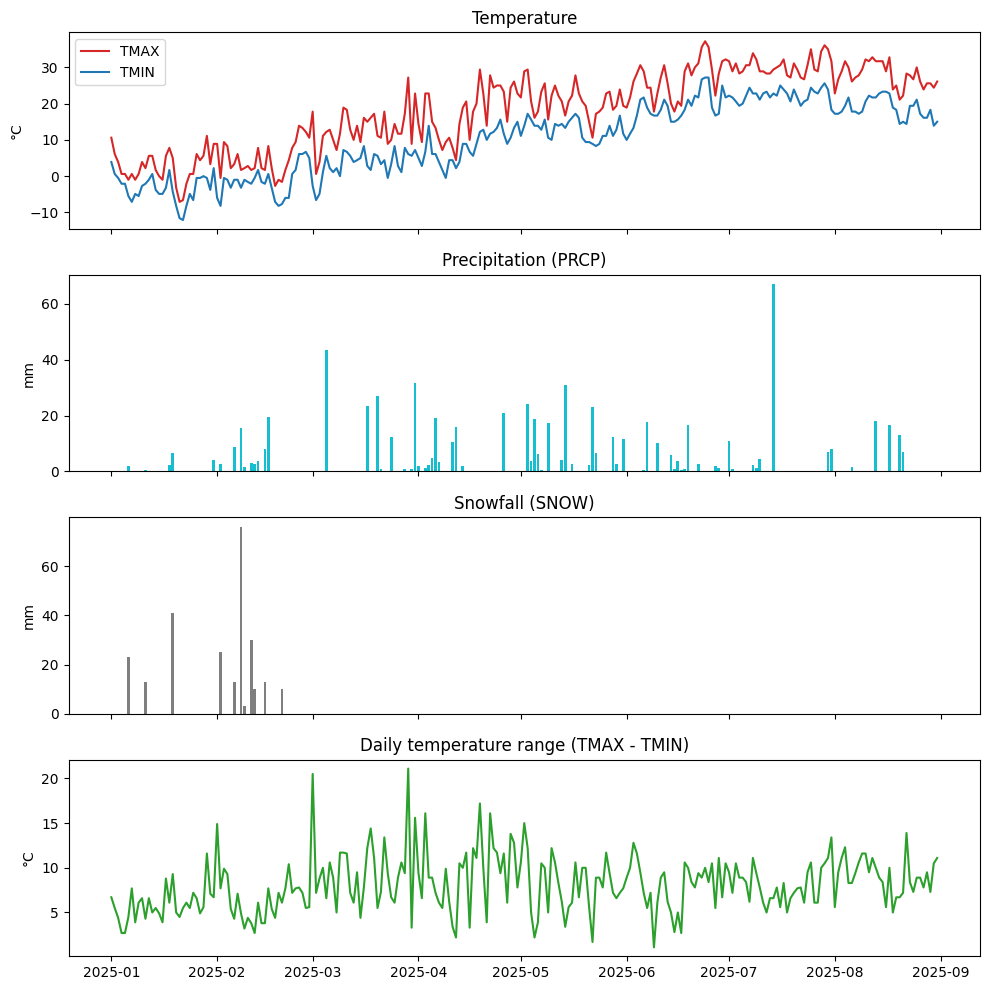

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].plot(wx["DATE"], wx["TMAX"], color="tab:red", label="TMAX")
axes[0].plot(wx["DATE"], wx["TMIN"], color="tab:blue", label="TMIN")
axes[0].set_ylabel("°C")
axes[0].legend()
axes[0].set_title("Temperature")

axes[1].bar(wx["DATE"], wx["PRCP"], color="tab:cyan")
axes[1].set_ylabel("mm")
axes[1].set_title("Precipitation (PRCP)")

axes[2].bar(wx["DATE"], wx["SNOW"], color="tab:gray")
axes[2].set_ylabel("mm")
axes[2].set_title("Snowfall (SNOW)")

axes[3].plot(wx["DATE"], wx["TMAX"] - wx["TMIN"], color="tab:green")
axes[3].set_ylabel("°C")
axes[3].set_title("Daily temperature range (TMAX - TMIN)")

plt.tight_layout()
plt.savefig("../figures/fig_00_weather_overview.png", dpi=300)
plt.show()

## Sanity-check units

`units=metric` was requested explicitly from the API (see `00_download.ipynb`). NYC TMAX should
be roughly -15..40 °C; if the raw GHCN tenths-of-degree convention had leaked through instead,
values would look like ~arbitrary integers in the hundreds (e.g. 250 instead of 25.0).

In [4]:
print("TMAX range:", wx["TMAX"].min(), "..", wx["TMAX"].max())
print("TMIN range:", wx["TMIN"].min(), "..", wx["TMIN"].max())
print("PRCP range:", wx["PRCP"].min(), "..", wx["PRCP"].max())
print("SNOW range:", wx["SNOW"].min(), "..", wx["SNOW"].max())

assert wx["TMAX"].max() < 50 and wx["TMIN"].min() > -30, "temperature values implausible for metric C -- check units"
assert (wx["PRCP"].dropna() >= 0).all(), "negative precipitation found"
assert (wx["SNOW"].dropna() >= 0).all(), "negative snowfall found"
print("units plausibility checks passed")

TMAX range: -7.1 .. 37.2
TMIN range: -12.1 .. 27.2
PRCP range: 0.0 .. 67.1
SNOW range: 0.0 .. 76.0
units plausibility checks passed


## Missing calendar days

In [5]:
full_calendar = pd.date_range(wx["DATE"].min(), wx["DATE"].max(), freq="D")
missing_days = full_calendar.difference(wx["DATE"])
print(f"expected days: {len(full_calendar)}, present days: {wx['DATE'].nunique()}, missing days: {len(missing_days)}")
if len(missing_days):
    print(missing_days)

print()
print("missing values within present rows, per column:")
print(wx.isna().mean().round(4) * 100)

expected days: 243, present days: 243, missing days: 0

missing values within present rows, per column:
STATION    0.0
DATE       0.0
PRCP       0.0
SNOW       0.0
TMAX       0.0
TMIN       0.0
dtype: float64


## Notes for later phases

- No missing calendar days in this window (2025-01-01..2025-08-31): 243/243 days present.
- Units confirmed plausible for °C / mm as requested (`units=metric`).
- Full quality assessment (including a check for missing weather days re-run in the eventual
  8-month vs 4-month subset actually used for analysis) happens in `03_quality.ipynb`.